In [5]:
import pandas as pd
import json as js

In [4]:
calphed_data = pd.read_csv(r"Data\calphad_alloys_train_opt.csv")

In [10]:
Dmax_dict = js.load(open(r"Data\dmax_data.json", "r"))
y_data = [Dmax_dict[alloy] for alloy in calphed_data["alloy_string"]]

In [11]:
calphed_data.drop(columns=["alloy_string"], inplace=True)

In [13]:
print(f"X shape: {calphed_data.shape}, y length: {len(y_data)}")
print(f"Num columns: {len(calphed_data.columns)}")

X shape: (882, 82008), y length: 882
Num columns: 82008


In [14]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

X = calphed_data.values
y = np.array(y_data)

# Train/test split for a quick sanity check
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Shallow tree to get preliminary feature importances fast
tree = DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42)
tree.fit(X_train, y_train)

print(f"Train R²: {tree.score(X_train, y_train):.4f}")
print(f"Test  R²: {tree.score(X_test, y_test):.4f}")

Train R²: 0.8160
Test  R²: -0.0160


In [15]:
# Get feature importances and rank them
importances = tree.feature_importances_
col_names = calphed_data.columns

# Build a sorted dataframe of non-zero importances
feat_imp = pd.DataFrame({
    "feature": col_names,
    "importance": importances
})
feat_imp = feat_imp[feat_imp["importance"] > 0].sort_values("importance", ascending=False).reset_index(drop=True)

print(f"Features used by tree: {len(feat_imp)} out of {len(col_names)}\n")
print(feat_imp.to_string())

Features used by tree: 41 out of 82008

                  feature  importance
0         DF_CU5ZR_T1050C    0.178966
1          NF_GDMG2_T500C    0.167392
2        DF_AL9CO2_T2100C    0.084474
3           DF_AGTI_T950C    0.077508
4          NF_CUZR2_T700C    0.063744
5      DF_LAVES_C15_T350C    0.048599
6          NF_NIZR2_T750C    0.043054
7      DF_LAVES_C15_T400C    0.038846
8          DF_AL3NI2_T50C    0.032406
9      DF_LAVES_C36_T400C    0.028188
10       DF_AL3NI2_T1750C    0.026578
11    DF_LAVES_C15_T1150C    0.018036
12           DF_CRB_T350C    0.016455
13       DF_MG24Y5_T2250C    0.016153
14         DF_D_GAMMA_T0C    0.015453
15     DF_LAVES_C14_T150C    0.014874
16       DF_CO17Y2_T1200C    0.012700
17        DF_CU5ZR_T1100C    0.011189
18    DF_LAVES_C15_T2500C    0.010378
19    DF_LAVES_C14_T2000C    0.009779
20         DF_CU4LA_T400C    0.008615
21  DF_FEUZR_DELTA_T1100C    0.008566
22          DF_CUTI_T550C    0.008515
23        NF_LIQUID_T350C    0.007944
24        

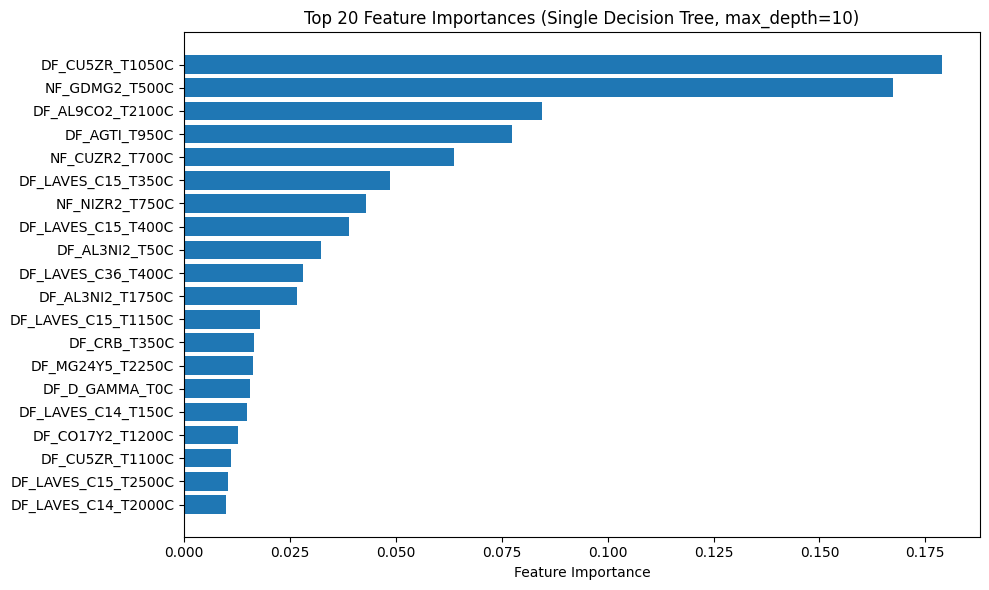

In [16]:
import matplotlib.pyplot as plt

top_n = min(20, len(feat_imp))
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feat_imp["feature"][:top_n][::-1], feat_imp["importance"][:top_n][::-1])
ax.set_xlabel("Feature Importance")
ax.set_title(f"Top {top_n} Feature Importances (Single Decision Tree, max_depth=10)")
plt.tight_layout()
plt.show()

In [17]:
import re

# Parse each column into prefix (DF/NF), phase name, and temperature
records = []
for col, imp in zip(col_names, importances):
    m = re.match(r'^(DF|NF)_(.+)_(T\d+C)$', col)
    if m:
        records.append({
            "feature": col,
            "prefix": m.group(1),
            "phase": m.group(2),
            "temperature": m.group(3),
            "importance": imp
        })

all_feats = pd.DataFrame(records)

# --- Aggregate by temperature ---
by_temp = all_feats.groupby("temperature")["importance"].sum().sort_values(ascending=False)
by_temp = by_temp[by_temp > 0]

# --- Aggregate by prefix (DF vs NF) ---
by_prefix = all_feats.groupby("prefix")["importance"].sum().sort_values(ascending=False)

# --- Aggregate by prefix + temperature ---
by_prefix_temp = all_feats.groupby(["prefix", "temperature"])["importance"].sum().sort_values(ascending=False)
by_prefix_temp = by_prefix_temp[by_prefix_temp > 0]

print("=== Importance by Temperature ===")
print(by_temp.to_string())
print(f"\n=== Importance by Prefix (DF vs NF) ===")
print(by_prefix.to_string())
print(f"\n=== Importance by Prefix + Temperature (non-zero) ===")
print(by_prefix_temp.to_string())

=== Importance by Temperature ===
temperature
T1050C    0.178966
T500C     0.167392
T2100C    0.084474
T950C     0.077508
T400C     0.075649
T350C     0.074948
T700C     0.066218
T750C     0.043054
T50C      0.032406
T1750C    0.026578
T1100C    0.022771
T1150C    0.018036
T2250C    0.016153
T650C     0.015465
T0C       0.015453
T1200C    0.015344
T150C     0.014874
T550C     0.012053
T2500C    0.010378
T2000C    0.009779
T250C     0.007422
T300C     0.005634
T900C     0.003814
T850C     0.002084
T1650C    0.001475
T2300C    0.001000
T1500C    0.000841
T1450C    0.000230

=== Importance by Prefix (DF vs NF) ===
prefix
DF    0.698806
NF    0.301194

=== Importance by Prefix + Temperature (non-zero) ===
prefix  temperature
DF      T1050C         0.178966
NF      T500C          0.167392
DF      T2100C         0.084474
        T950C          0.077508
        T400C          0.075649
        T350C          0.067004
NF      T700C          0.063744
        T750C          0.043054
DF      T50C 

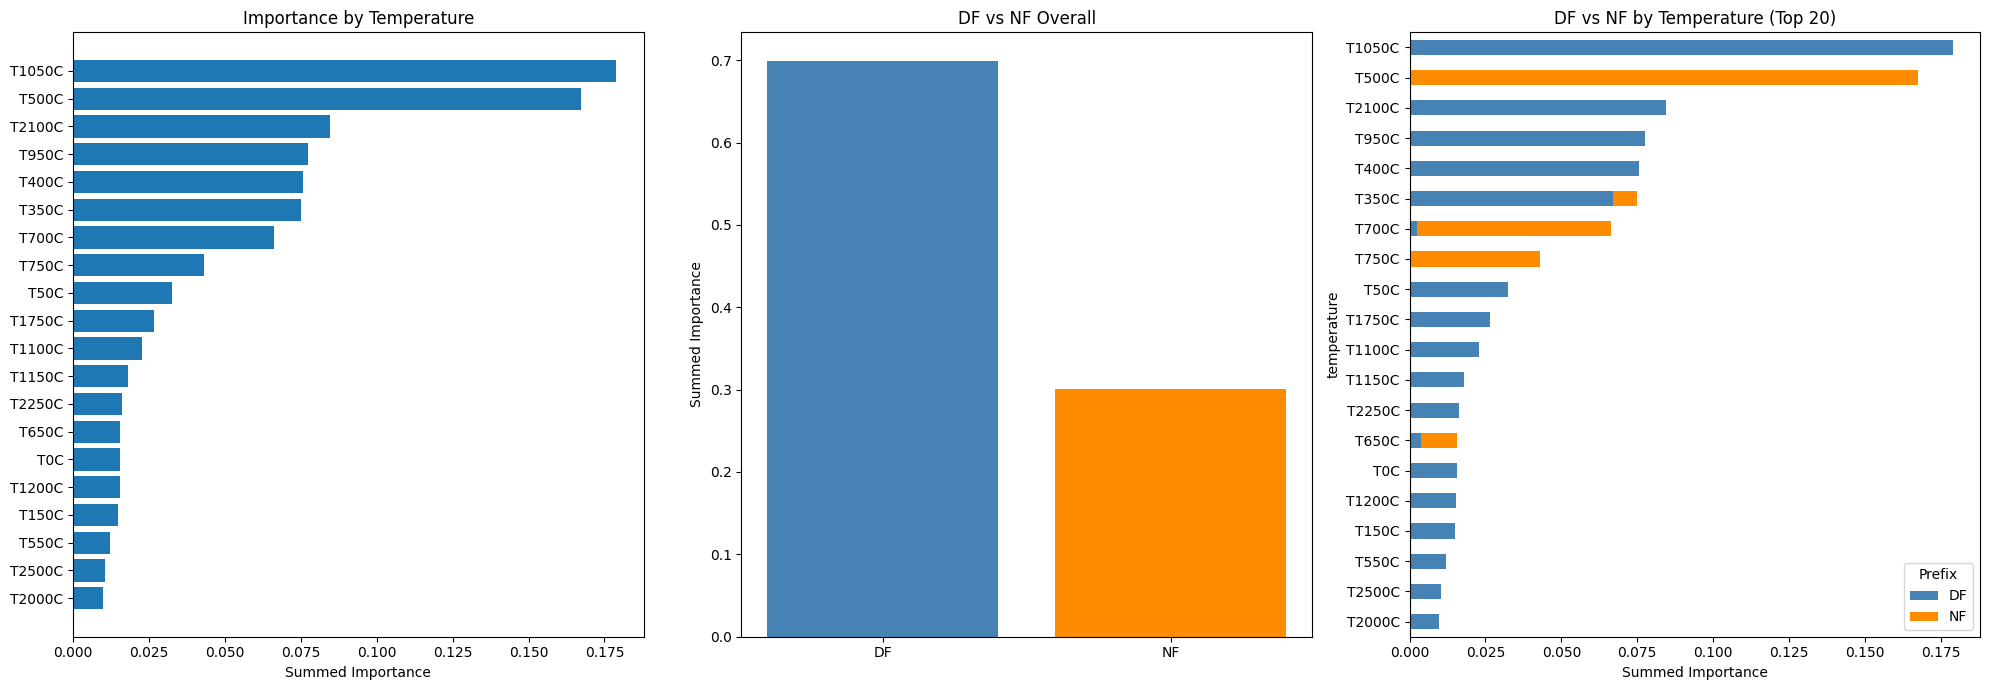

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# 1) By temperature
ax1 = axes[0]
by_temp_top = by_temp.head(20)
ax1.barh(by_temp_top.index[::-1], by_temp_top.values[::-1])
ax1.set_xlabel("Summed Importance")
ax1.set_title("Importance by Temperature")

# 2) DF vs NF
ax2 = axes[1]
ax2.bar(by_prefix.index, by_prefix.values, color=["steelblue", "darkorange"])
ax2.set_ylabel("Summed Importance")
ax2.set_title("DF vs NF Overall")

# 3) Prefix + Temperature (stacked bar)
ax3 = axes[2]
pivot = by_prefix_temp.reset_index()
pivot.columns = ["prefix", "temperature", "importance"]
pivot_wide = pivot.pivot(index="temperature", columns="prefix", values="importance").fillna(0)
# Sort by total importance
pivot_wide["total"] = pivot_wide.sum(axis=1)
pivot_wide = pivot_wide.sort_values("total", ascending=True).drop(columns="total").tail(20)
pivot_wide.plot.barh(stacked=True, ax=ax3, color={"DF": "steelblue", "NF": "darkorange"})
ax3.set_xlabel("Summed Importance")
ax3.set_title("DF vs NF by Temperature (Top 20)")
ax3.legend(title="Prefix")

plt.tight_layout()
plt.show()

In [19]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest with limited depth for speed on 82k features
rf = RandomForestRegressor(
    n_estimators=100, max_depth=10, min_samples_leaf=5,
    max_features="sqrt", n_jobs=-1, random_state=42
)
rf.fit(X_train, y_train)

print(f"Random Forest Train R²: {rf.score(X_train, y_train):.4f}")
print(f"Random Forest Test  R²: {rf.score(X_test, y_test):.4f}")

Random Forest Train R²: 0.7614
Random Forest Test  R²: 0.6708


In [20]:
# RF feature importances - aggregate by category (same parsing as before)
rf_importances = rf.feature_importances_

rf_records = []
for col, imp in zip(col_names, rf_importances):
    m = re.match(r'^(DF|NF)_(.+)_(T\d+C)$', col)
    if m:
        rf_records.append({
            "feature": col, "prefix": m.group(1),
            "phase": m.group(2), "temperature": m.group(3),
            "importance": imp
        })

rf_feats = pd.DataFrame(rf_records)

# Top individual features from RF
rf_top = rf_feats.sort_values("importance", ascending=False).head(30).reset_index(drop=True)
print("=== Top 30 RF Feature Importances ===")
print(rf_top[["feature", "importance"]].to_string())

# Aggregate by phase
rf_by_phase = rf_feats.groupby("phase")["importance"].sum().sort_values(ascending=False)
rf_by_phase_top = rf_by_phase[rf_by_phase > 0.005]  # filter noise

# Aggregate by temperature
rf_by_temp = rf_feats.groupby("temperature")["importance"].sum().sort_values(ascending=False).head(20)

# Aggregate by prefix
rf_by_prefix = rf_feats.groupby("prefix")["importance"].sum()

print(f"\n=== RF Importance by Prefix ===")
print(rf_by_prefix.to_string())
print(f"\n=== RF Importance by Phase (>0.5%) ===")
print(rf_by_phase_top.to_string())

=== Top 30 RF Feature Importances ===
                     feature  importance
0            DF_GDMG5_T1000C    0.004032
1       DF_AGSB_ORTHO_T2100C    0.004019
2            DF_ALZR2_T1350C    0.003827
3         DF_AGCD_ETA_T2400C    0.003430
4       DF_ALCU_THETA_T2500C    0.003326
5   DF_ALCE_AMORPHOUS_T2300C    0.003312
6             NF_GDMG2_T200C    0.003211
7         DF_AGCD_ETA_T2450C    0.003202
8           DF_CUPD_B2_T950C    0.003006
9       DF_AGSB_ORTHO_T2250C    0.002909
10           DF_CU5ZR_T1800C    0.002862
11           DF_CU5ZR_T2100C    0.002810
12           DF_GDMG5_T2100C    0.002753
13             NF_GDMG2_T50C    0.002668
14            DF_GDMG5_T850C    0.002659
15        DF_AGCD_ETA_T2050C    0.002640
16          DF_CU4TI3_T2150C    0.002630
17          DF_AL4ZR5_T1700C    0.002560
18          DF_AL3NI2_T2450C    0.002554
19           DF_CU4TI3_T300C    0.002536
20           DF_ALPT3_T2150C    0.002480
21  DF_ALCE_AMORPHOUS_T2200C    0.002442
22         DF_AL11C

In [22]:
from sklearn.inspection import permutation_importance

# Permutation importance on the full test set
# This shuffles each feature one at a time and measures the R² drop
# With 82k features this is expensive, so we limit repeats
perm_result = permutation_importance(
    rf, X_test, y_test,
    n_repeats=5, random_state=42, n_jobs=-1,
    scoring="r2"
)

perm_df = pd.DataFrame({
    "feature": col_names,
    "perm_importance_mean": perm_result.importances_mean,
    "perm_importance_std": perm_result.importances_std
}).sort_values("perm_importance_mean", ascending=False).reset_index(drop=True)

# Show features with positive permutation importance
perm_positive = perm_df[perm_df["perm_importance_mean"] > 0]
print(f"Features with positive permutation importance: {len(perm_positive)}\n")
print(perm_positive.head(30).to_string())

Features with positive permutation importance: 1824

                     feature  perm_importance_mean  perm_importance_std
0       DF_AGSB_ORTHO_T2100C              0.005555             0.001203
1           DF_AL4ZR5_T1700C              0.003667             0.000934
2         DF_AGCD_ETA_T2400C              0.003462             0.000614
3       DF_AGSB_ORTHO_T2250C              0.002767             0.000481
4            DF_ALPT3_T2300C              0.002744             0.000675
5   DF_ALCE_AMORPHOUS_T2300C              0.002682             0.000957
6       DF_ALCU_THETA_T2450C              0.002595             0.000691
7           DF_CUPD_B2_T950C              0.002495             0.000549
8          DF_ALM_D019_T650C              0.002456             0.000784
9            DF_ALPT3_T1800C              0.002451             0.000787
10          DF_AL4ZR5_T2050C              0.002428             0.000857
11          DF_AL5FE4_T2500C              0.002359             0.000821
12         

In [23]:
# Parse permutation importance features into categories
perm_records = []
for _, row in perm_df.iterrows():
    m = re.match(r'^(DF|NF)_(.+)_(T\d+C)$', row["feature"])
    if m:
        perm_records.append({
            "feature": row["feature"],
            "prefix": m.group(1),
            "phase": m.group(2),
            "temperature": m.group(3),
            "perm_imp": row["perm_importance_mean"]
        })

perm_feats = pd.DataFrame(perm_records)

# Aggregate permutation importance
perm_by_phase = perm_feats.groupby("phase")["perm_imp"].sum().sort_values(ascending=False)
perm_by_temp = perm_feats.groupby("temperature")["perm_imp"].sum().sort_values(ascending=False)
perm_by_prefix = perm_feats.groupby("prefix")["perm_imp"].sum()
perm_by_prefix_temp = perm_feats.groupby(["prefix", "temperature"])["perm_imp"].sum().sort_values(ascending=False)

print("=== Permutation Importance by Prefix ===")
print(perm_by_prefix.to_string())
print(f"\n=== Permutation Importance by Phase (Top 30) ===")
print(perm_by_phase.head(30).to_string())
print(f"\n=== Permutation Importance by Temperature (Top 20) ===")
print(perm_by_temp.head(20).to_string())

=== Permutation Importance by Prefix ===
prefix
DF    0.287210
NF    0.003748

=== Permutation Importance by Phase (Top 30) ===
phase
AGSB_ORTHO        0.017908
AGCD_ETA          0.017638
ALPT3             0.012096
AL4ZR5            0.011665
ALCE_AMORPHOUS    0.010763
AL3ZR2            0.010512
AL5FE4            0.009323
CU51ZR14          0.009235
AL2ZR3            0.008886
ALZR2             0.008589
ALLI              0.007890
ALTI              0.007684
HCP_A3            0.006764
AL8CR5_ALPHA      0.006646
ALZR              0.006576
AL3NI2            0.006352
ALM_D019          0.005983
AGTI              0.005931
AL11CR2           0.005835
AGZR2             0.005636
CUZR2             0.005633
CUB_A13           0.005574
AL3NB             0.005554
BCC_A2            0.005331
CUPD_B2           0.005144
AGZR              0.004943
BCT_A5            0.004722
ALZR3             0.004722
AL3ZR5            0.004532
FEUZR_DELTA       0.004350

=== Permutation Importance by Temperature (Top 20) ===


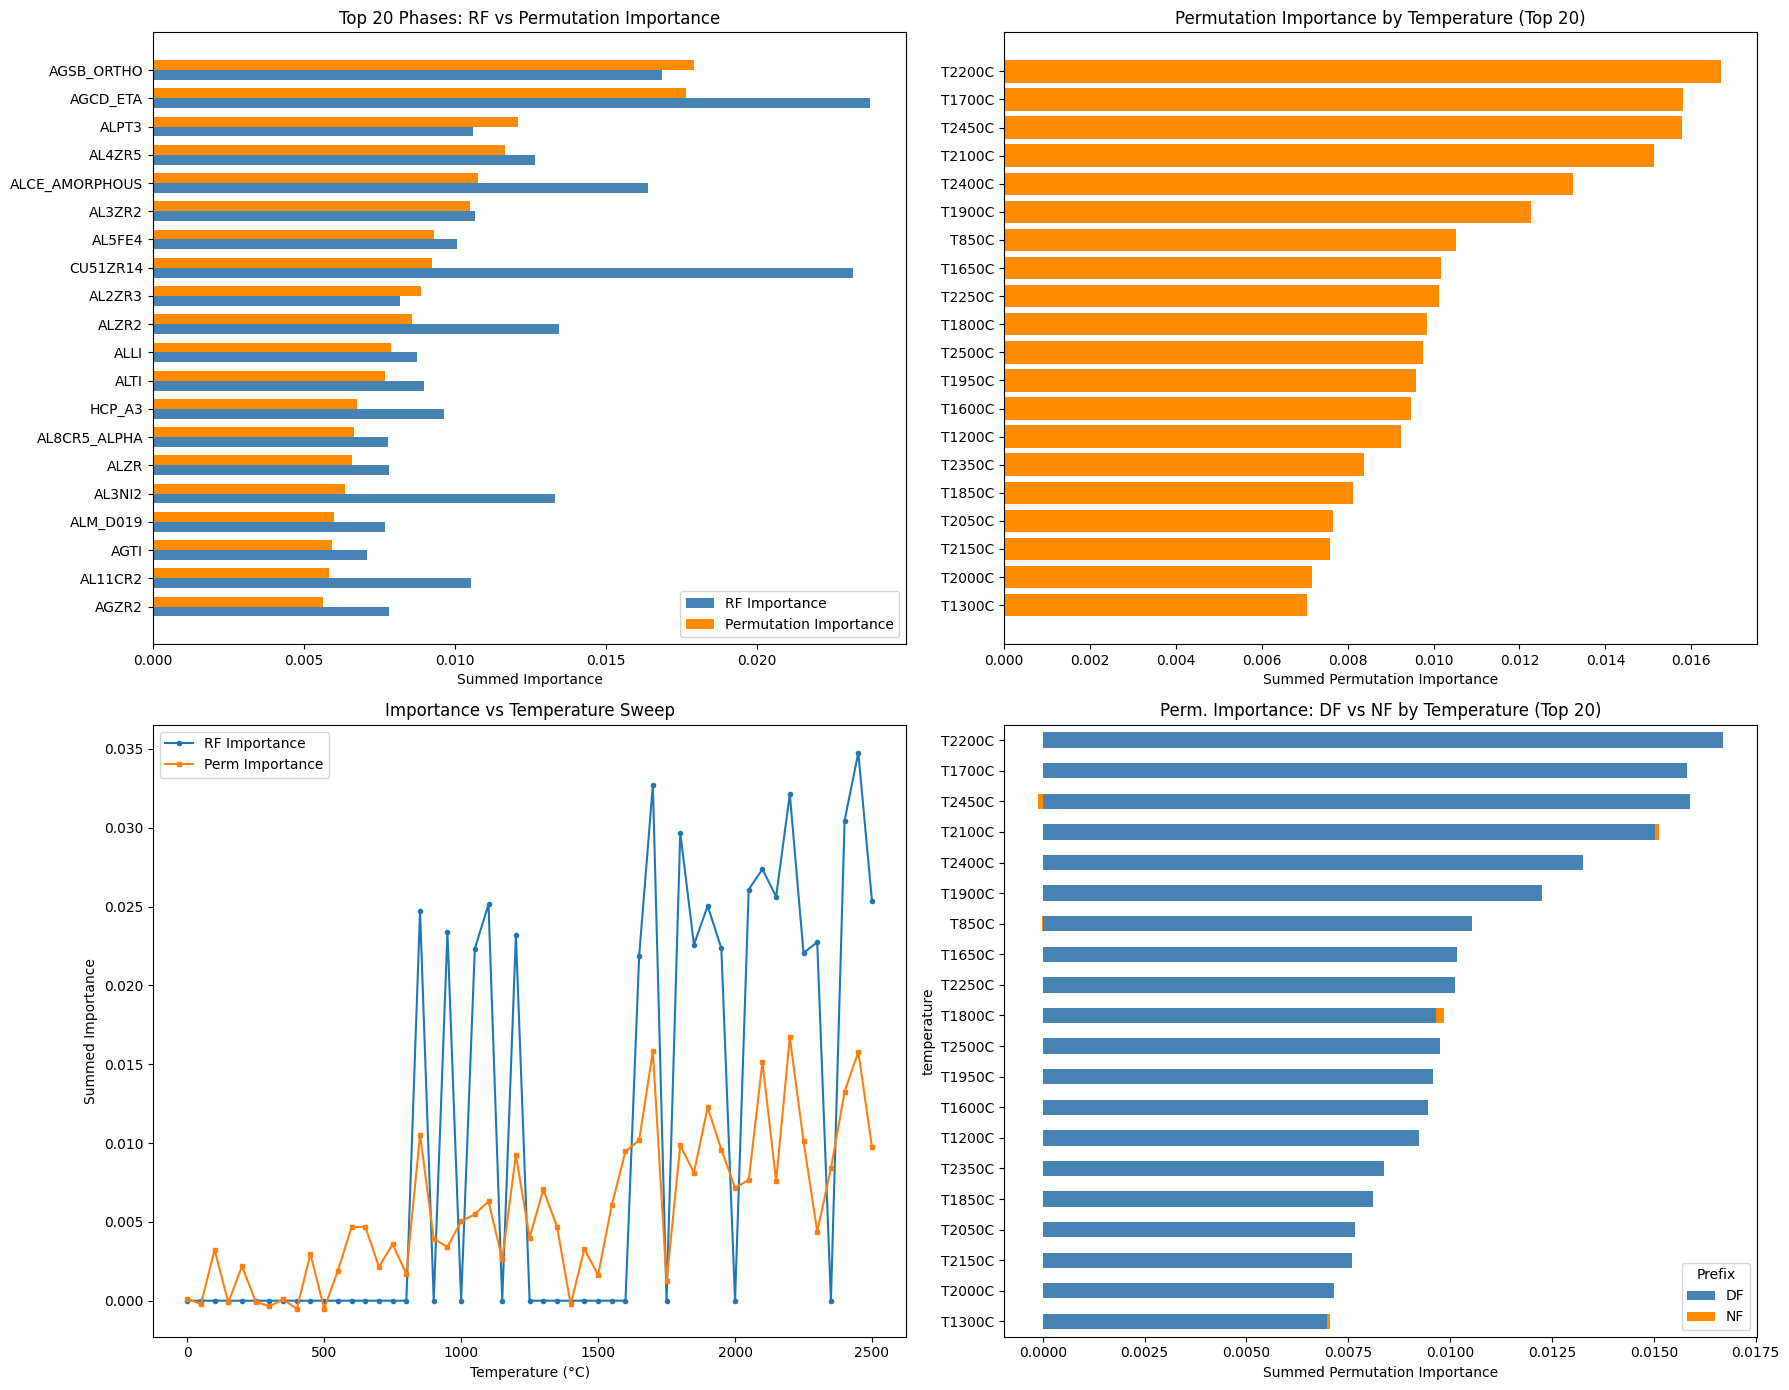

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1) RF vs Permutation: Top phases
ax = axes[0, 0]
top_phases = perm_by_phase.head(20)
rf_phase_vals = rf_by_phase.reindex(top_phases.index).fillna(0)
x_pos = np.arange(len(top_phases))
w = 0.35
ax.barh(x_pos + w/2, rf_phase_vals.values, w, label="RF Importance", color="steelblue")
ax.barh(x_pos - w/2, top_phases.values, w, label="Permutation Importance", color="darkorange")
ax.set_yticks(x_pos)
ax.set_yticklabels(top_phases.index)
ax.invert_yaxis()
ax.set_xlabel("Summed Importance")
ax.set_title("Top 20 Phases: RF vs Permutation Importance")
ax.legend()

# 2) Permutation importance by temperature
ax = axes[0, 1]
perm_temp_top = perm_by_temp.head(20)
ax.barh(perm_temp_top.index[::-1], perm_temp_top.values[::-1], color="darkorange")
ax.set_xlabel("Summed Permutation Importance")
ax.set_title("Permutation Importance by Temperature (Top 20)")

# 3) RF importance by temperature vs Permutation importance by temperature
ax = axes[1, 0]
# Extract numeric temperatures for proper ordering
def temp_to_num(t):
    return int(re.search(r'\d+', t).group())

all_temps = sorted(set(rf_by_temp.index) | set(perm_by_temp.index), key=temp_to_num)
rf_t = rf_by_temp.reindex(all_temps).fillna(0)
perm_t = perm_by_temp.reindex(all_temps).fillna(0)
ax.plot([temp_to_num(t) for t in all_temps], rf_t.values, 'o-', label="RF Importance", markersize=3)
ax.plot([temp_to_num(t) for t in all_temps], perm_t.values, 's-', label="Perm Importance", markersize=3)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Summed Importance")
ax.set_title("Importance vs Temperature Sweep")
ax.legend()

# 4) Permutation importance DF vs NF breakdown by temperature
ax = axes[1, 1]
perm_pt = perm_by_prefix_temp.reset_index()
perm_pt.columns = ["prefix", "temperature", "importance"]
perm_pivot = perm_pt.pivot(index="temperature", columns="prefix", values="importance").fillna(0)
perm_pivot["total"] = perm_pivot.sum(axis=1)
perm_pivot = perm_pivot.sort_values("total", ascending=True).drop(columns="total").tail(20)
perm_pivot.plot.barh(stacked=True, ax=ax, color={"DF": "steelblue", "NF": "darkorange"})
ax.set_xlabel("Summed Permutation Importance")
ax.set_title("Perm. Importance: DF vs NF by Temperature (Top 20)")
ax.legend(title="Prefix")

plt.tight_layout()
plt.show()